In [54]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [55]:
df = pd.read_csv("/content/pass.csv")
df

,password,strength,length,class_strength,entropy,crack_time_sec,crack_time
0,bybee,0.088053,5,Very week,11.609640,1.562500e-06,instant
1,n3m0,0.088889,4,Very week,8.000000,1.280000e-07,instant
2,2509,0.088889,4,Very week,8.000000,1.280000e-07,instant
3,4622,0.070443,4,Very week,8.000000,1.280000e-07,instant
4,shrk,0.088889,4,Very week,8.000000,1.280000e-07,instant
...,...,...,...,...,...,...,...
99995,sifelizestasdecirmeloquerras,0.932150,28,Very strong,134.605938,1.657276e+31,Eternity
99996,iwillalwayslovemyboyfriend,0.915039,26,Very strong,122.211433,3.078060e+27,Eternity
99997,letsyouupdateyourfunNotesandmore,0.956727,32,Very strong,160.000000,7.307508e+38,Eternity
99998,chocolatesoeusi912134741,0.900241,24,Very strong,110.039100,6.668679e+23,Eternity


In [56]:
print(df.head())
print(df.shape)
print(df.columns)

  password  strength  length class_strength   entropy  crack_time_sec  \
0    bybee  0.088053       5      Very week  11.60964    1.562500e-06   
1     n3m0  0.088889       4      Very week   8.00000    1.280000e-07   
2     2509  0.088889       4      Very week   8.00000    1.280000e-07   
3     4622  0.070443       4      Very week   8.00000    1.280000e-07   
4     shrk  0.088889       4      Very week   8.00000    1.280000e-07   

  crack_time  
0    instant  
1    instant  
2    instant  
3    instant  
4    instant  
(100000, 7)
Index(['password', 'strength', 'length', 'class_strength', 'entropy',
       'crack_time_sec', 'crack_time'],
      dtype='object')


In [57]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
password          0
strength          0
length            0
class_strength    0
entropy           0
crack_time_sec    0
crack_time        0
dtype: int64


In [58]:
df = df.dropna(subset=['password', 'strength'])

In [59]:
common_words = [
    "password",
    "admin",
    "welcome",
    "hello",
    "qwerty",
    "letmein",
    "monkey",
    "dragon",
    "football",
    "sunshine",
    "computer",
    "login",
    "user",
    "india"
]

In [60]:
def extract_features(password):

    password = str(password)

    length = len(password)

    uppercase = sum(c.isupper() for c in password)

    lowercase = sum(c.islower() for c in password)

    digits = sum(c.isdigit() for c in password)

    special = sum(not c.isalnum() for c in password)

    dictionary_word = 0

    password_lower = password.lower()

    for word in common_words:
        if word in password_lower:
            dictionary_word = 1
            break

    return [
        length,
        uppercase,
        lowercase,
        digits,
        special,
        dictionary_word
    ]

In [61]:
features = df['password'].apply(extract_features)

X = pd.DataFrame(
    features.tolist(),
    columns=[
        'length',
        'uppercase',
        'lowercase',
        'digits',
        'special',
        'dictionary_word'
    ]
)

In [62]:
y = df['class_strength']

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nClass distribution:")
print(y.value_counts())


Features:
   length  uppercase  lowercase  digits  special  dictionary_word
0       5          0          5       0        0                0
1       4          0          2       2        0                0
2       4          0          0       4        0                0
3       4          0          0       4        0                0
4       4          0          4       0        0                0

Target:
0    Very week
1    Very week
2    Very week
3    Very week
4    Very week
Name: class_strength, dtype: object

Class distribution:
class_strength
Very week      20040
Average        20008
Very strong    20000
Strong         19992
Week           19960
Name: count, dtype: int64


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 80000
Testing samples: 20000


In [64]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [65]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [66]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("precision")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.92085

Confusion Matrix:
[[3711  281    0    0   10]
 [ 215 3592  191    0    0]
 [   0  101 3897    2    0]
 [   2    3    7 3525  471]
 [ 198    5    0   97 3692]]

Classification Report:
              precision    recall  f1-score   support

     Average       0.90      0.93      0.91      4002
      Strong       0.90      0.90      0.90      3998
 Very strong       0.95      0.97      0.96      4000
   Very week       0.97      0.88      0.92      4008
        Week       0.88      0.92      0.90      3992

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000



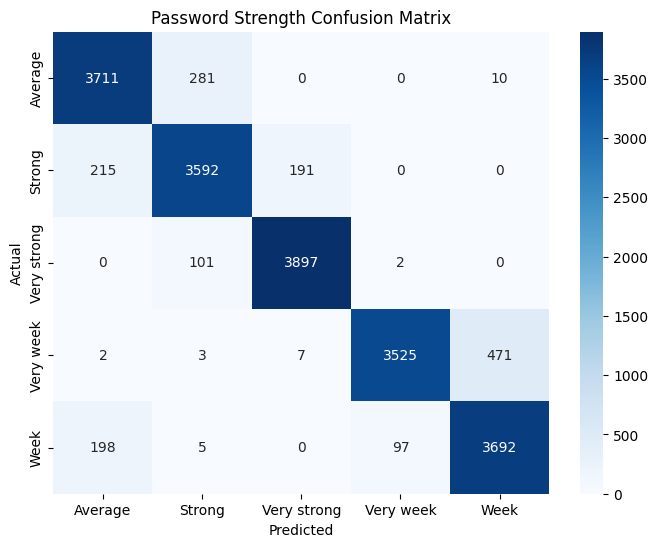

In [67]:
cm = confusion_matrix(y_test, y_pred)

labels = sorted(y.unique())

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Password Strength Confusion Matrix")

plt.show()

In [68]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

           Feature  Importance
0           length    0.702897
2        lowercase    0.205562
3           digits    0.070688
1        uppercase    0.016814
4          special    0.003343
5  dictionary_word    0.000696


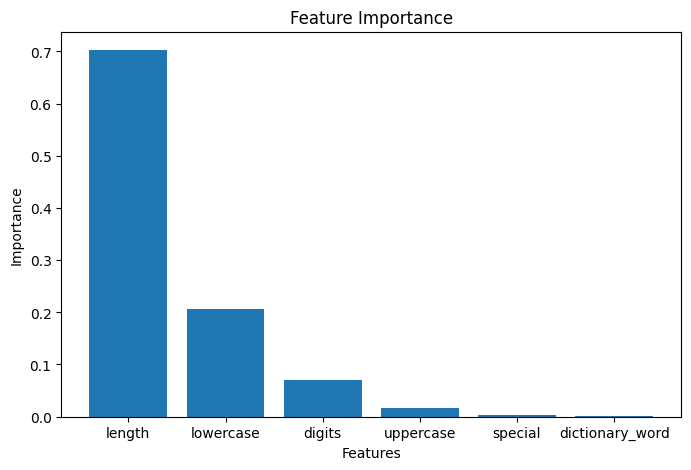

In [69]:
plt.figure(figsize=(8, 5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()